In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [3]:
print(f"Shape: {X.shape}")
print(f"Class balance: {pd.Series(y).value_counts()}")
print(X.describe())

Shape: (569, 30)
Class balance: 1    357
0    212
Name: count, dtype: int64
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 1. Train a Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42) # Depth limited for interpretability
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

In [7]:
# 2. Train Logistic Regression
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [8]:
# 3. Compare metrics
print("--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}")
print(classification_report(y_test, dt_preds))

print("\n--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

--- Decision Tree Performance ---
Accuracy: 0.9474
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Logistic Regression Performance ---
Accuracy: 0.9561
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114




--- Decision Tree Rules ---
|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- mean texture <= 16.19
|   |   |   |--- class: 1
|   |   |--- mean texture >  16.19
|   |   |   |--- class: 0
|--- mean concave points >  0.05
|   |--- worst concave points <= 0.15
|   |   |--- worst perimeter <= 115.25
|   |   |   |--- class: 1
|   |   |--- worst perimeter >  115.25
|   |   |   |--- class: 0
|   |--- worst concave points >  0.15
|   |   |--- fractal dimension error <= 0.01
|   |   |   |--- class: 0
|   |   |--- fractal dimension error >  0.01
|   |   |   |--- class: 1



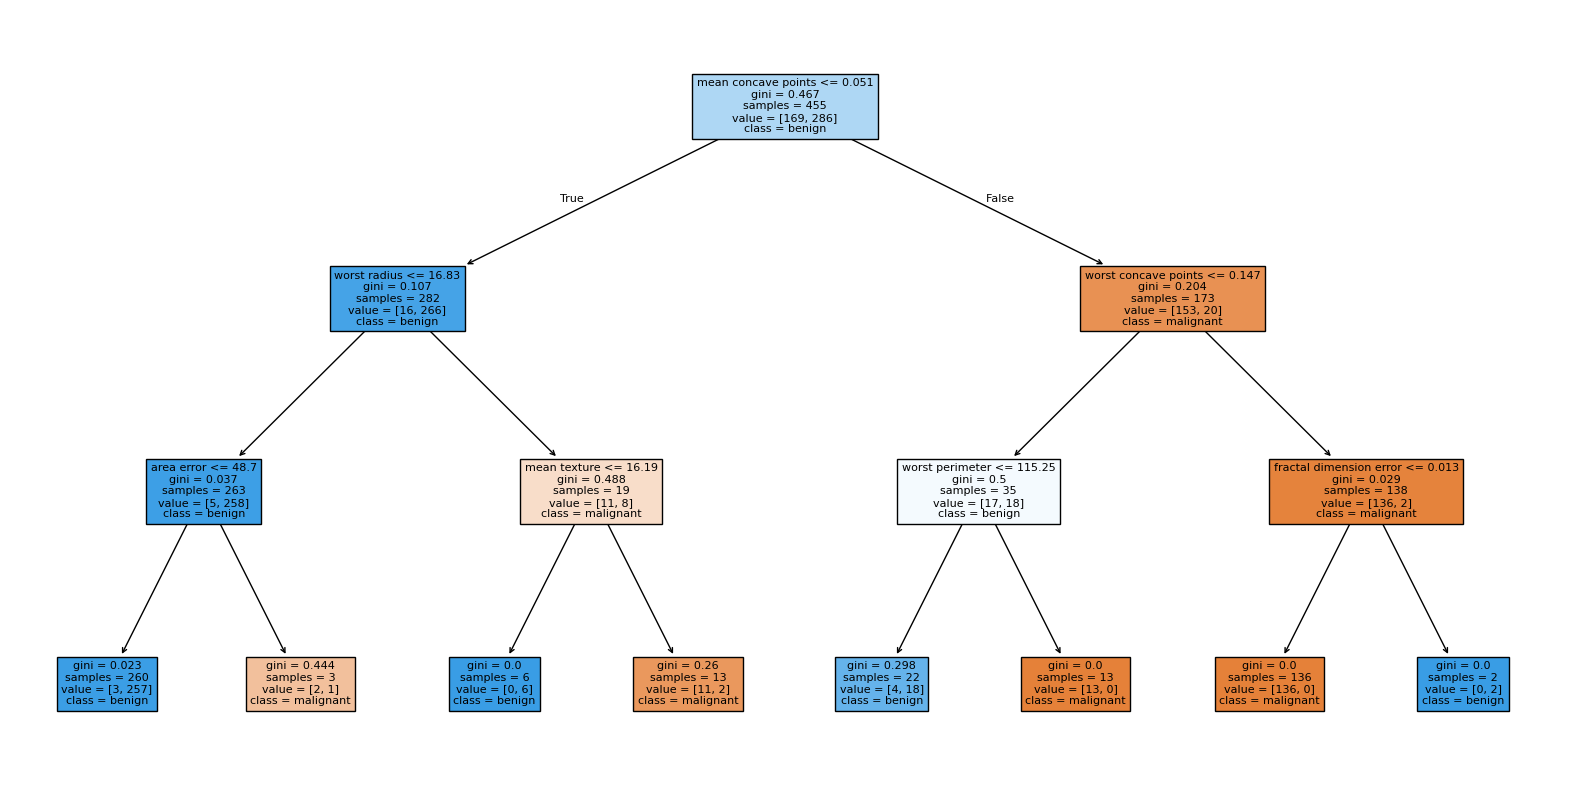

In [9]:
# 4. Look at the Decision Tree structure
from sklearn.tree import export_text, plot_tree

print("\n--- Decision Tree Rules ---")
tree_rules = export_text(dt_model, feature_names=list(data.feature_names))
print(tree_rules)

# Visualize the tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()